# Homework 4

This notebook follows the exercise sheet in `s4_hw.pdf`.
Questions 2 to 9 use the raw `hitec` returns from `s4_data.txt`.
Question 1 estimates the Laplace regression directly on raw `hitec` and `mkt` returns.


In [1]:
import pandas as pd

from homework04 import (
    exercise_1_MLE,
    exercise_2_ljung_box_squared_hitec,
    exercise_3_ARCH4_model1,
    exercise_4_ARCH4_model1_oos_volatility,
    exercise_5_var_10day_95,
    exercise_6_ARCH4_model2_t,
    exercise_7_GJR11_model3_t,
    exercise_8_compare_model2_model3,
    exercise_9_compare_aic,
)


In [2]:
raw_df = pd.read_csv("./s4_data.txt", sep="\t")
raw_df.head()

,date,nodur,durbl,manuf,enrgy,hitec,telcm,shops,hlth,utils,other,mktrf,smb,hml,rf,dol,gold,silver,mkt
0,1990-01-03,-0.36,-0.11,0.36,-1.32,0.28,-0.57,0.30,0.56,-0.53,0.26,-0.06,0.75,-0.32,0.026,0.150102,-1.405621,-0.608268,-0.034
1,1990-01-04,-0.99,-0.38,-0.40,-1.11,0.42,-1.90,-0.30,-0.53,-1.28,-0.39,-0.71,0.43,-0.25,0.026,-1.302764,1.125442,2.200500,-0.684
2,1990-01-05,-0.56,-1.02,-0.58,-1.04,-0.48,-1.87,-0.53,-1.34,-1.31,-0.39,-0.85,0.76,-0.23,0.026,-0.039676,1.924345,0.954434,-0.824
3,1990-01-08,-0.27,0.19,0.39,1.08,0.66,1.13,0.24,0.57,-0.17,-0.08,0.30,-0.42,-0.24,0.026,-0.300461,-0.793896,-1.337976,0.326
4,1990-01-09,-1.08,-0.41,-0.92,-1.23,-0.85,-1.48,-1.12,-1.03,-0.62,-0.83,-1.01,0.87,0.09,0.026,0.455704,0.315775,-0.204752,-0.984


## Exercise 1

We estimate the Laplace regression

$$
R_t^{\mathrm{hitec}} = \beta_0 + \beta_1 R_t^{\mathrm{mkt}} + u_t,\qquad u_t \sim \mathcal{L}(0,s).
$$

Under the Laplace density, the log-likelihood is

$$
\ell(\beta_0,\beta_1,s) = -n\log(2s) - \sum_{t=1}^n \frac{|u_t|}{s}.
$$

The sheet asks us to report $\beta_0$, $\beta_1$, and their standard errors.


In [3]:
results_ex1 = exercise_1_MLE(raw_df)
results_ex1["summary"]

,parameter,estimate,std_error
0,beta0,0.017754,0.008179
1,beta1,1.166466,0.003693
2,s,0.546480,0.006614


## Exercise 2

To test for ARCH effects, we apply the Ljung-Box test to squared `hitec` returns.
The null hypothesis is

$$
H_0:\ \rho_1(hitec_t^2)=\rho_2(hitec_t^2)=\cdots=\rho_{12}(hitec_t^2)=0.
$$

Rejecting $H_0$ means there is autocorrelation in squared returns, which is evidence of ARCH effects.


In [4]:
results_ex2 = exercise_2_ljung_box_squared_hitec(raw_df, lags=12)
results_ex2["summary"]


,test,series,lags,lb_stat,p_value,reject_h0
0,Ljung-Box,hitec^2,12,3573.233534,0.0,True


In [5]:
results_ex2["conclusion"]


'Reject H0 at the 5% level: squared hitec returns are autocorrelated, so there is evidence of ARCH effects.'

## Exercise 3

Model 1 is an ARCH(4) model with normal innovations:

$$
r_t = \mu + u_t, \qquad u_t = \sigma_t z_t, \qquad z_t \sim N(0,1),
$$

$$
\sigma_t^2 = \omega + \alpha_1 u_{t-1}^2 + \alpha_2 u_{t-2}^2 + \alpha_3 u_{t-3}^2 + \alpha_4 u_{t-4}^2.
$$

The QQ plot of standardized residuals checks whether the normal innovation assumption is plausible.


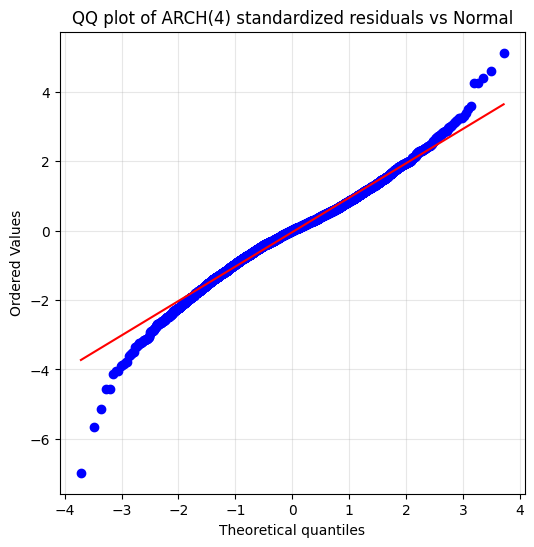

,parameter,estimate
0,mu,0.100817
1,omega,0.662570
2,alpha1,0.162762
3,alpha2,0.210222
4,alpha3,0.193642
5,alpha4,0.204005


In [6]:
results_ex3 = exercise_3_ARCH4_model1(raw_df, make_qq_plot=True)
results_ex3["summary"]


In [7]:
results_ex3["interpretation"]


'The QQ plot should deviate from the straight normal line, especially in the tails, so the normal innovation assumption is not fully convincing.'

## Exercise 4

We re-estimate Model 1 after dropping the last nine observations of the sample.
With the re-estimated parameters fixed, we then compute 10 one-step-ahead volatility forecasts: for the 9 held-out dates and for one additional forecast at $T+1$.


In [8]:
results_ex4 = exercise_4_ARCH4_model1_oos_volatility(raw_df)
results_ex4["forecasts"]


,horizon,target_label,date,sigma2_forecast,sigma_forecast,realized_hitec
0,1,2017-12-18,2017-12-18,0.897706,0.947474,0.89
1,2,2017-12-19,2017-12-19,1.011641,1.005804,-0.47
2,3,2017-12-20,2017-12-20,1.075397,1.037013,-0.13
3,4,2017-12-21,2017-12-21,1.090835,1.044430,-0.22
4,5,2017-12-22,2017-12-22,0.882778,0.939563,-0.17
5,6,2017-12-26,2017-12-26,0.775389,0.880562,-0.64
6,7,2017-12-27,2017-12-27,0.800542,0.894730,0.13
7,8,2017-12-28,2017-12-28,0.815740,0.903183,0.12
8,9,2017-12-29,2017-12-29,0.786410,0.886798,-0.62
9,10,T+1,NaT,0.861650,0.928251,NaN


## Exercise 5

Based on the 10 volatility forecasts from Question 4, we compute a 10-day 95% VaR under conditional normality.

$$
R_{t,t+10} \mid \mathcal{F}_t \sim N\!\left(10\mu, \sum_{h=1}^{10} \sigma_{t+h|t+h-1}^2\right).
$$

Hence the 5% return quantile is

$$
q_{0.05} = 10\mu + z_{0.05} \sqrt{\sum_{h=1}^{10} \sigma_{t+h|t+h-1}^2},
$$

and the 95% loss VaR is

$$
\mathrm{VaR}_{0.95} = -q_{0.05}.
$$


In [9]:
results_ex5 = exercise_5_var_10day_95(results_ex4)
results_ex5["summary"]


,measure,value
0,daily_mu,0.101298
1,mean_10d,1.012978
2,sd_10d,2.999682
3,z_0.05,-1.644854
4,VaR_5pct_return_quantile,-3.921059
5,VaR_95_loss,3.921059


## Exercise 6

Model 2 keeps the ARCH(4) variance equation but replaces normal innovations by a Student-t distribution.
The shape parameter $\nu$ controls tail thickness: smaller values imply heavier tails.
This is the parameter the sheet asks us to report and relate to the QQ-plot comment from Question 3.


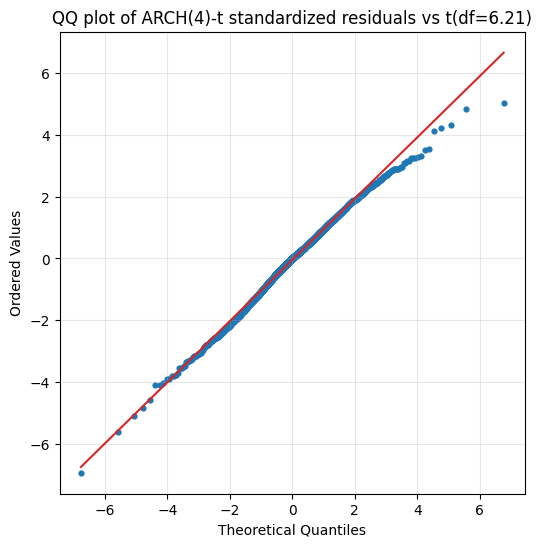

,parameter,estimate
0,mu,0.107058
1,omega,0.663775
2,alpha1,0.140665
3,alpha2,0.206700
4,alpha3,0.214369
5,alpha4,0.230613
6,shape,6.210218


In [10]:
results_ex6 = exercise_6_ARCH4_model2_t(raw_df, make_qq_plot=True)
results_ex6["summary"]


In [11]:
results_ex6["interpretation"]


'The estimated shape coefficient is 6.210. This is far from the normal limit, so the t model captures heavy tails and supports the tail deviations seen in Question 3.'

## Exercise 7

Model 3 is a GJR(1,1) model with Student-t innovations:

$$
\sigma_t^2 = \omega + \alpha u_{t-1}^2 + \gamma \mathbf{1}_{\{u_{t-1}<0\}} u_{t-1}^2 + \beta \sigma_{t-1}^2.
$$

The coefficient $\gamma$ measures asymmetry.
If $\gamma > 0$, negative shocks increase next-period variance more than positive shocks of the same size.
The sheet asks whether variance goes up or down after a negative shock and whether that effect is significant at the 5% level.


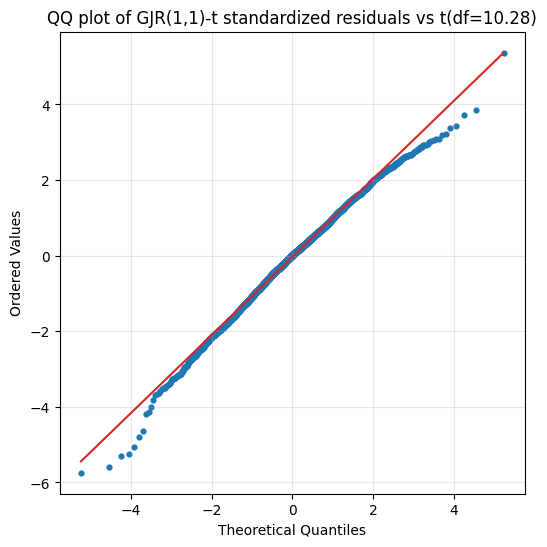

,parameter,estimate,std_error
0,mu,0.095585,0.012935
1,omega,0.019022,0.004485
2,alpha,0.057719,0.006479
3,gamma,0.022174,0.006050
4,beta,0.916308,0.009102
5,shape,10.276975,1.056964


In [12]:
results_ex7 = exercise_7_GJR11_model3_t(
    raw_df,
    model1=results_ex3,
    model2=results_ex6,
    make_qq_plot=True,
)
results_ex7["summary"]


In [13]:
results_ex7["interpretation"]


'Variance goes up after a negative shock. The effect is statistically significant at the 5% level. (gamma = 0.0222, p-value = 0.0002)'

## Exercise 8

For Model 2 and Model 3 we report:

- the ACF of standardized residuals (plot 10)
- the ACF of squared standardized residuals (plot 11)

The first diagnostic checks whether linear dependence is left in the residuals.
The second diagnostic checks whether volatility clustering is still left after fitting the model.
We display 20 lags as a diagnostic window.


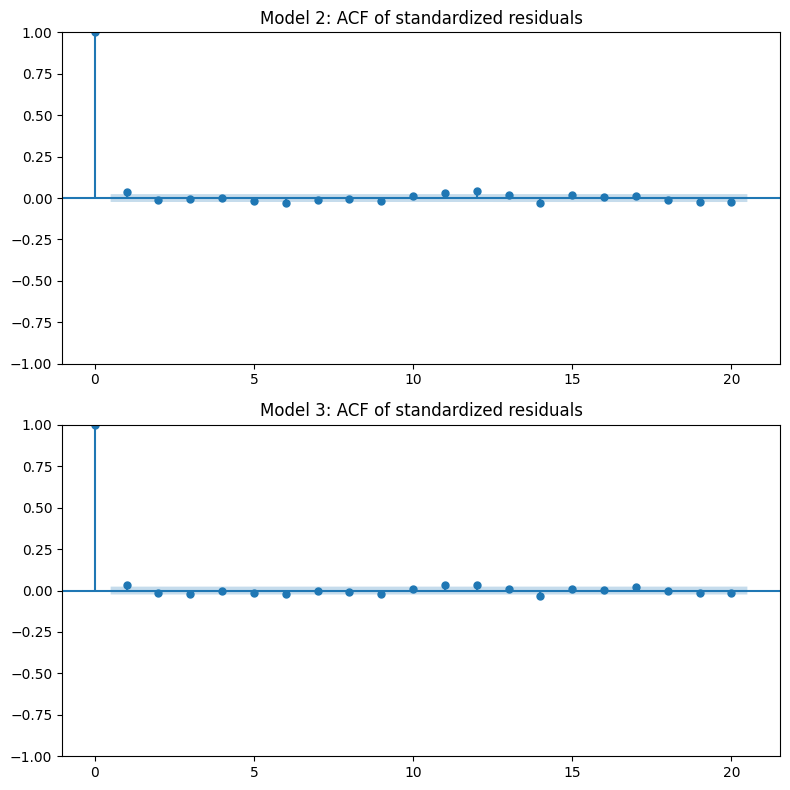

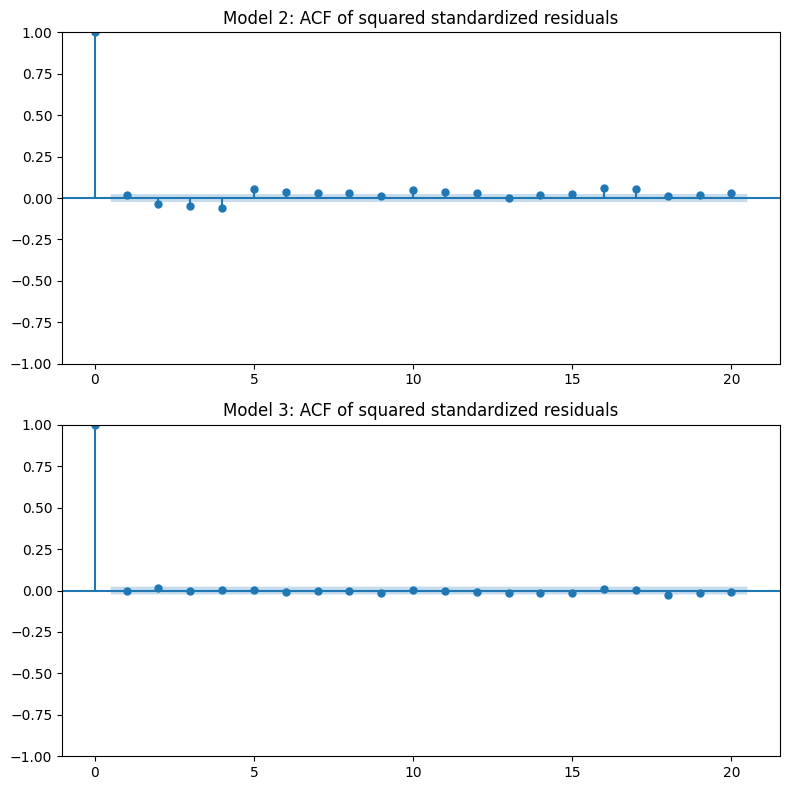

,model,lb_std_stat,lb_std_pvalue,lb_std_sq_stat,lb_std_sq_pvalue,acf_score
0,Model 2: ARCH(4)-t,60.458060,0.000006,194.384735,1.447200e-30,1.028360
1,"Model 3: GJR(1,1)-t",51.798752,0.000122,17.520798,6.189431e-01,0.512161


In [14]:
results_ex8 = exercise_8_compare_model2_model3(
    model2_result=results_ex6,
    model3_result=results_ex7,
    lags=20,
)
results_ex8["diagnostics"]


In [15]:
results_ex8["interpretation"]


'Model 3: GJR(1,1)-t leaves less residual dependence overall. In Question 8 the most important diagnostic is the ACF of squared standardized residuals, because it shows whether volatility clustering is still left in the residuals.'

## Exercise 9

We compare the three fitted volatility models with the Akaike Information Criterion

$$
\mathrm{AIC} = 2k - 2\log L.
$$

Lower AIC means a better fit-parsimony trade-off.


In [16]:
results_ex9 = exercise_9_compare_aic(results_ex3, results_ex6, results_ex7)
results_ex9["comparison"]


,model,n_params,loglik,AIC,rank
0,"Model 3: GJR(1,1)-t",6,-11383.085845,22778.171691,1
1,Model 2: ARCH(4)-t,7,-11615.199910,23244.399820,2
2,Model 1: ARCH(4)-normal,6,-11759.185431,23530.370862,3


In [17]:
results_ex9["interpretation"]


'Model 3 has the lowest AIC, so both heavy tails and asymmetric volatility matter for the hitec return series.'